In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df_mesures = pd.read_csv('exctraction_crystallizer (1)\exctraction_crystallizer.csv') 
df_instruments = pd.read_excel(
    '826-Crystallizer Mapping-TEN-Officiel.xlsx'
)

df_merged = df_mesures.merge(df_instruments, left_on='Tag', right_on='Instrument TAG ID', how='left')

df_merged['Measure_Date'] = pd.to_datetime(df_merged['Measure_Date'])

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_1256\611161639.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  df_mesures = pd.read_csv('exctraction_crystallizer (1)\exctraction_crystallizer.csv')


In [3]:
df_instruments.head()

,Equipement Type,Equipement TAG IG,Instrument TAG ID,Instrument Description,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Common 826,NaN,826FQR23,Feed flow meter for all crystallizers,NaN,NaN,NaN,NaN
1,Common 826,NaN,826FQR23_Zh,"Integration over flow rate, therefore mass",NaN,NaN,NaN,NaN
2,CRYSTALLIZER 1,U-82601-01,826P-82601,"Slurry transfer pump, operating sensor",NaN,NaN,NaN,NaN
3,CRYSTALLIZER 1,U-82601-01,826XV16,3-way supply valve,NaN,NaN,NaN,NaN
4,CRYSTALLIZER 1,U-82601-01,826SRK02,Agitator speed,NaN,NaN,NaN,NaN


In [4]:
df_mesures.head()

,Unnamed: 0,Tag,Value,Measure_Date,nom de campagne
0,0,826LR06,1.24,2025-08-28 23:00:44,Kampagne 5
1,1,826LR06,1.24,2025-08-28 23:00:45,Kampagne 5
2,2,826LR06,1.24,2025-08-28 23:00:46,Kampagne 5
3,3,826LR06,1.24,2025-08-28 23:00:47,Kampagne 5
4,4,826LR06,1.25,2025-08-28 23:00:48,Kampagne 5


In [5]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23983403 entries, 0 to 23983402
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   Unnamed: 0              int64         
 1   Tag                     object        
 2   Value                   float64       
 3   Measure_Date            datetime64[ns]
 4   nom de campagne         object        
 5   Equipement Type         object        
 6   Equipement TAG IG       object        
 7   Instrument TAG ID       object        
 8   Instrument Description  object        
 9   Unnamed: 4              float64       
 10  Unnamed: 5              float64       
 11  Unnamed: 6              float64       
 12  Unnamed: 7              object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 2.3+ GB


In [6]:
df_merged.head()

,Unnamed: 0,Tag,Value,Measure_Date,nom de campagne,Equipement Type,Equipement TAG IG,Instrument TAG ID,Instrument Description,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,0,826LR06,1.24,2025-08-28 23:00:44,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
1,1,826LR06,1.24,2025-08-28 23:00:45,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
2,2,826LR06,1.24,2025-08-28 23:00:46,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
3,3,826LR06,1.24,2025-08-28 23:00:47,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
4,4,826LR06,1.25,2025-08-28 23:00:48,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN


In [7]:
# Pivot : On met le temps en index et chaque Tag devient une colonne
df_pivot = df_merged.pivot_table(index='Measure_Date', 
                                columns='Tag', 
                                values='Value')

In [8]:
df_pivot.head()

Tag,826FQR23,826LR05,826LR06,826TRC07,826TRC07_DeltaT,826TRC08,826TRC08_DeltaT,826TRC09,826TRC09_DeltaT,826XV01,826XV14,826XV16,826XV18,P-82601
Measure_Date,,,,,,,,,,,,,,
2025-08-27 11:00:45,NaN,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:46,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:47,-4.03,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:48,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,NaN,NaN,NaN,NaN,NaN


In [9]:
# On crée un dictionnaire {Tag: Description} à partir du référentiel
mapping = dict(zip(df_instruments['Instrument TAG ID'], df_instruments['Instrument Description']))
df_pivot.rename(columns=mapping, inplace=True)

print(df_pivot.head())

Tag                  Feed flow meter for all crystallizers  % of level  \
Measure_Date                                                             
2025-08-27 11:00:45                                    NaN       -0.03   
2025-08-27 11:00:46                                  -4.07       -0.03   
2025-08-27 11:00:47                                  -4.03       -0.03   
2025-08-27 11:00:48                                  -4.07       -0.03   
2025-08-27 11:00:49                                  -3.87       -0.03   

Tag                  % of level  Temperature  Temperature ramp  Temperature  \
Measure_Date                                                                  
2025-08-27 11:00:45        1.13          NaN               NaN          NaN   
2025-08-27 11:00:46        1.13          NaN               NaN          NaN   
2025-08-27 11:00:47        1.13          NaN               NaN          NaN   
2025-08-27 11:00:48        1.13          NaN               NaN          NaN   
2025-08

In [10]:
df_pivot.head()

Tag,Feed flow meter for all crystallizers,% of level,% of level,Temperature,Temperature ramp,Temperature,Temperature ramp,Temperature,Temperature ramp,Crystallizer bottom on/off valve,Crystallizer bottom on/off valve,3-way supply valve,On/off power supply valve,P-82601
Measure_Date,,,,,,,,,,,,,,
2025-08-27 11:00:45,NaN,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:46,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:47,-4.03,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:48,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
df_pivot.columns

Index(['Feed flow meter for all crystallizers', '% of level', '% of level',
       'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp',
       'Temperature', 'Temperature ramp', 'Crystallizer bottom on/off valve',
       'Crystallizer bottom on/off valve', '3-way supply valve',
       'On/off power supply valve', 'P-82601'],
      dtype='object', name='Tag')

C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_1256\125271232.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


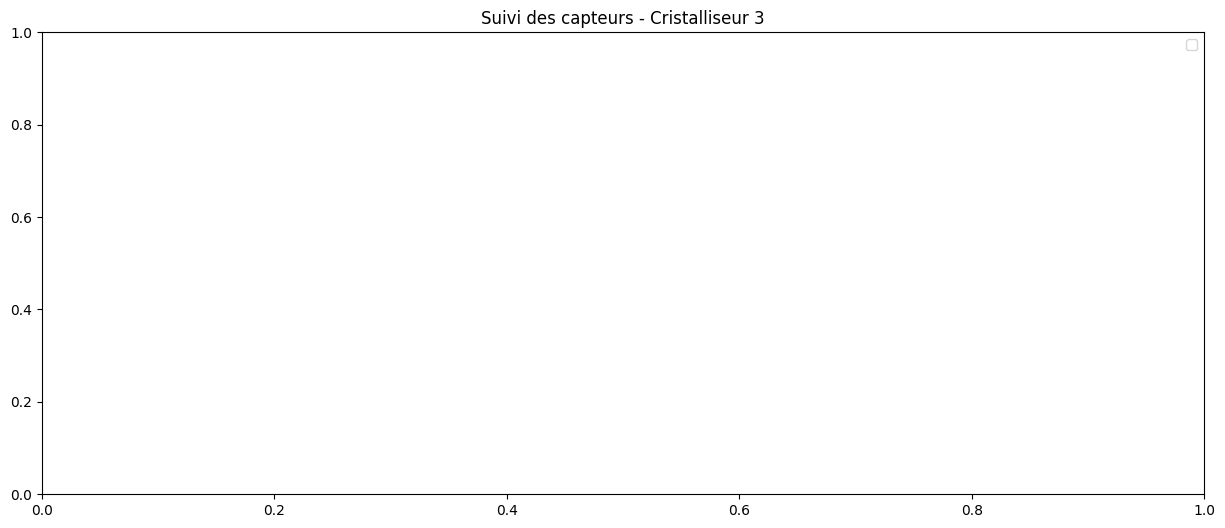

In [12]:
# On affiche par exemple les capteurs liés au CRYSTALLIZER 3 (vu dans tes images)
capteurs_c3 = [col for col in df_pivot.columns if '826LR06' in col or '826TRC09' in col]

plt.figure(figsize=(15, 6))
for capteur in capteurs_c3:
    plt.plot(df_pivot.index, df_pivot[capteur], label=capteur)

plt.title('Suivi des capteurs - Cristalliseur 3')
plt.legend()
plt.show()

In [13]:
# Vérifiez le format dans votre CSV. Si c'est 2025-08-28 :
df_merged['Measure_Date'] = pd.to_datetime(df_merged['Measure_Date'], errors='coerce')

# Supprimez les lignes où la date est invalide (NaT)
df_merged = df_merged.dropna(subset=['Measure_Date'])

In [14]:
df_merged.describe()

,Unnamed: 0,Value,Measure_Date,Unnamed: 4,Unnamed: 5,Unnamed: 6
count,2.398340e+07,2.398340e+07,23983403,0.0,0.0,0.0
mean,4.240561e+06,9.218743e+00,2025-10-23 23:31:20.728733184,NaN,NaN,NaN
min,0.000000e+00,-1.546301e+04,2025-08-27 11:00:45,NaN,NaN,NaN
25%,1.998616e+06,-3.000000e-02,2025-09-07 11:13:39,NaN,NaN,NaN
50%,3.997233e+06,0.000000e+00,2025-11-09 01:52:15,NaN,NaN,NaN
75%,6.309923e+06,1.000000e-02,2025-11-20 20:07:50,NaN,NaN,NaN
max,1.012082e+07,1.056496e+04,2025-12-10 11:01:50,NaN,NaN,NaN
std,2.663736e+06,2.145267e+02,NaN,NaN,NaN,NaN


Colonnes disponibles dans le pivot : ['Feed flow meter for all crystallizers', '% of level', '% of level', 'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp', 'Crystallizer bottom on/off valve', 'Crystallizer bottom on/off valve', '3-way supply valve', 'On/off power supply valve', 'P-82601']


C:\Users\MohamedNadirHAMOU\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


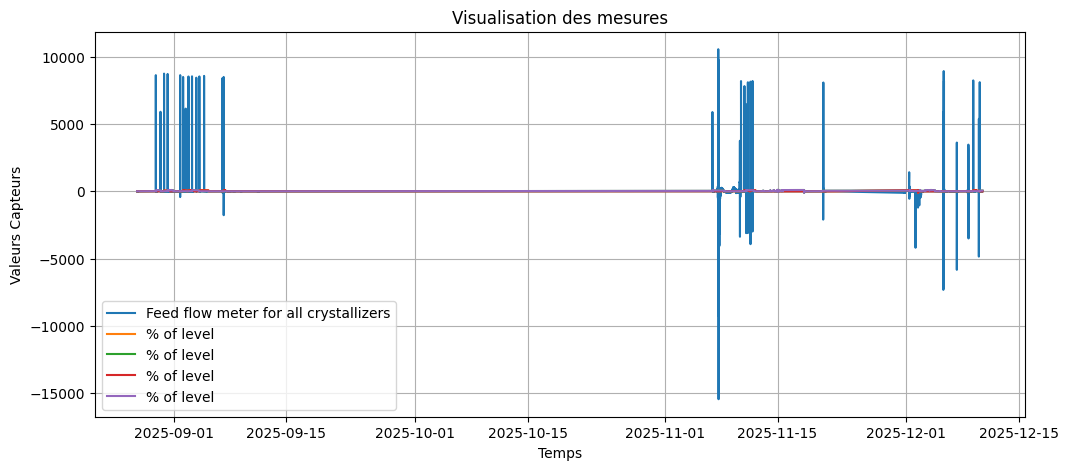

In [15]:
import matplotlib.pyplot as plt

print("Colonnes disponibles dans le pivot :", df_pivot.columns.tolist())

cols_to_plot = df_pivot.columns[:3] 

plt.figure(figsize=(12, 5))
for col in cols_to_plot:

    data_to_plot = df_pivot[col].dropna()
    plt.plot(data_to_plot.index, data_to_plot.values, label=col)

plt.title("Visualisation des mesures")
plt.xlabel("Temps")
plt.ylabel("Valeurs Capteurs")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
print(df_pivot.shape) 
print(df_pivot.isnull().sum()) 

(3799310, 14)
Tag
Feed flow meter for all crystallizers      36579
% of level                                 12799
% of level                                 28759
Temperature                              3363517
Temperature ramp                           12787
Temperature                              3363205
Temperature ramp                           14993
Temperature                              3363863
Temperature ramp                           14322
Crystallizer bottom on/off valve         3799257
Crystallizer bottom on/off valve         3799274
3-way supply valve                       3799253
On/off power supply valve                3799266
P-82601                                  3799120
dtype: int64


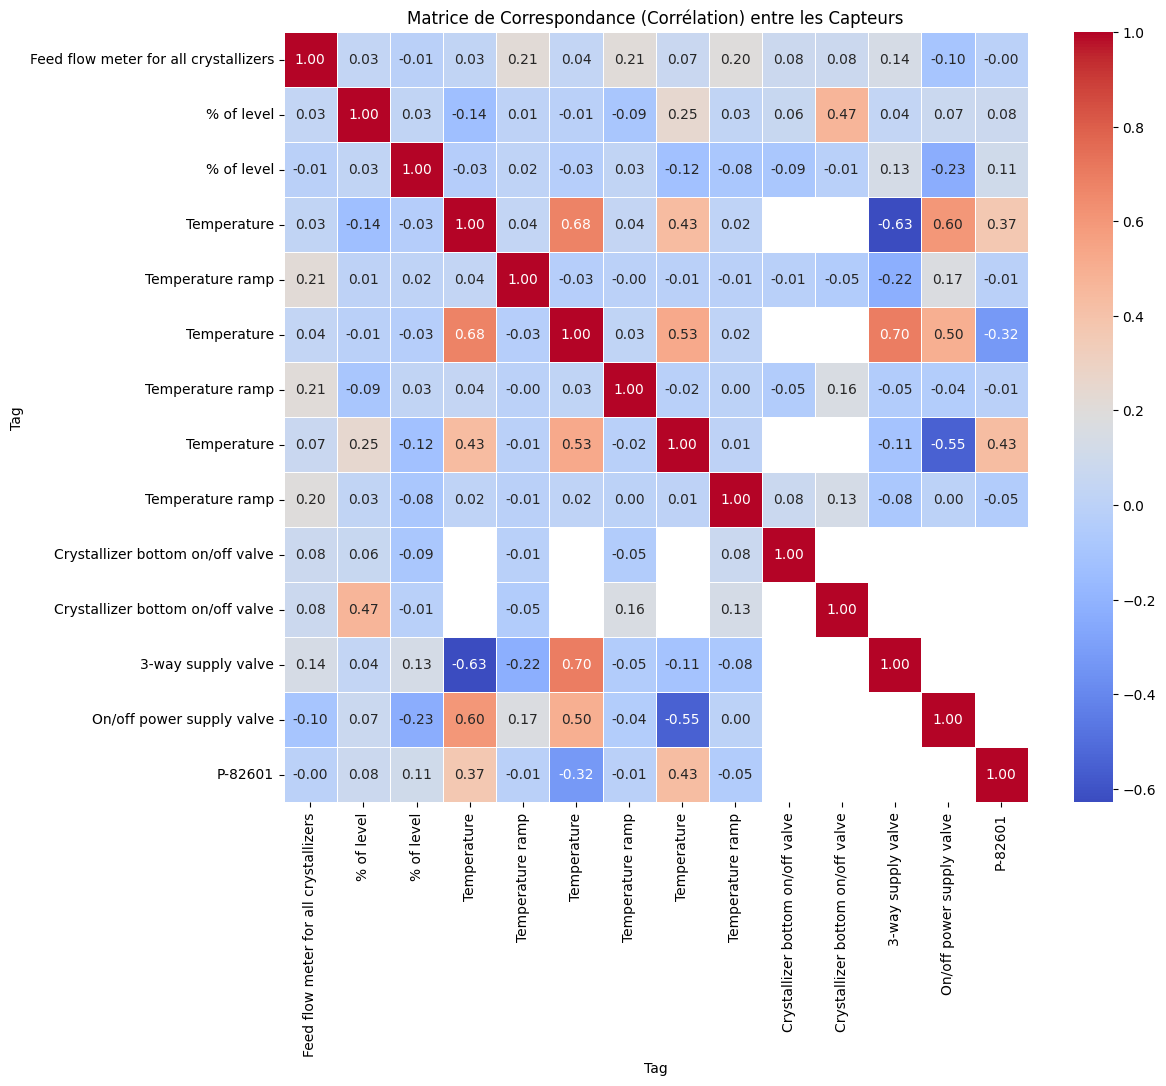

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_pivot.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matrice de Correspondance (Corrélation) entre les Capteurs')
plt.show()

C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_1256\2310453713.py:3: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_pivot_sync = df_pivot.resample('10S').mean().ffill()


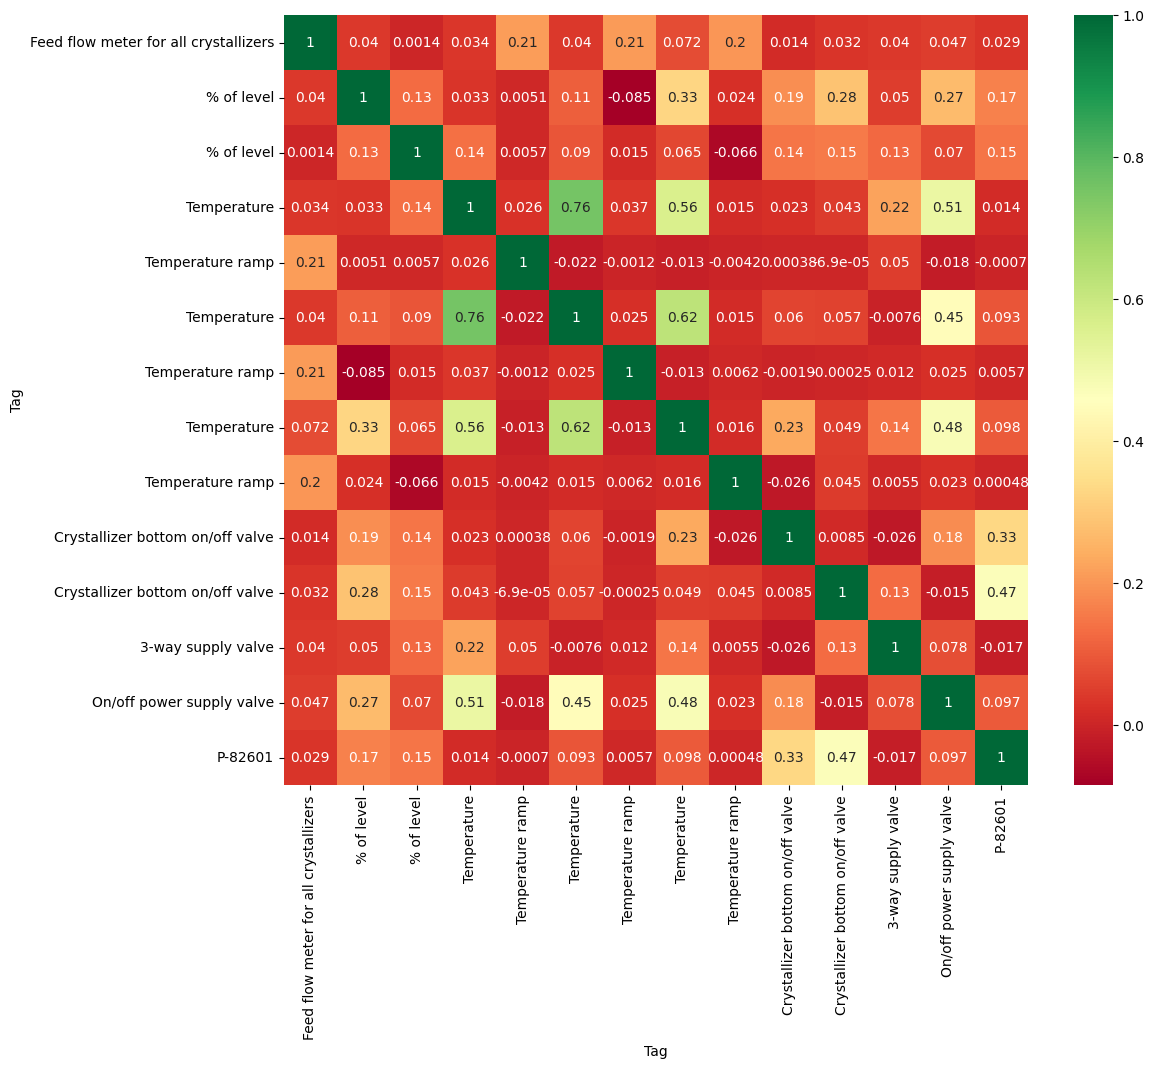

In [18]:
# Synchronisation : on crée une ligne toutes les 10 secondes et on remplit les trous
# '10S' = 10 secondes. Tu peux mettre '1T' pour 1 minute.
df_pivot_sync = df_pivot.resample('10S').mean().ffill()

# Maintenant, on calcule la corrélation sur les données synchronisées
corr_matrix_sync = df_pivot_sync.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_sync, annot=True, cmap='RdYlGn')
plt.show()

In [19]:
df_instruments['Unique_Name'] = df_instruments['Instrument TAG ID'] + " - " + df_instruments['Instrument Description']

mapping_unique = dict(zip(df_instruments['Instrument TAG ID'], df_instruments['Unique_Name']))

df_pivot.rename(columns=mapping_unique, inplace=True)

print(df_pivot.columns.tolist())

['Feed flow meter for all crystallizers', '% of level', '% of level', 'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp', 'Crystallizer bottom on/off valve', 'Crystallizer bottom on/off valve', '3-way supply valve', 'On/off power supply valve', 'P-82601']


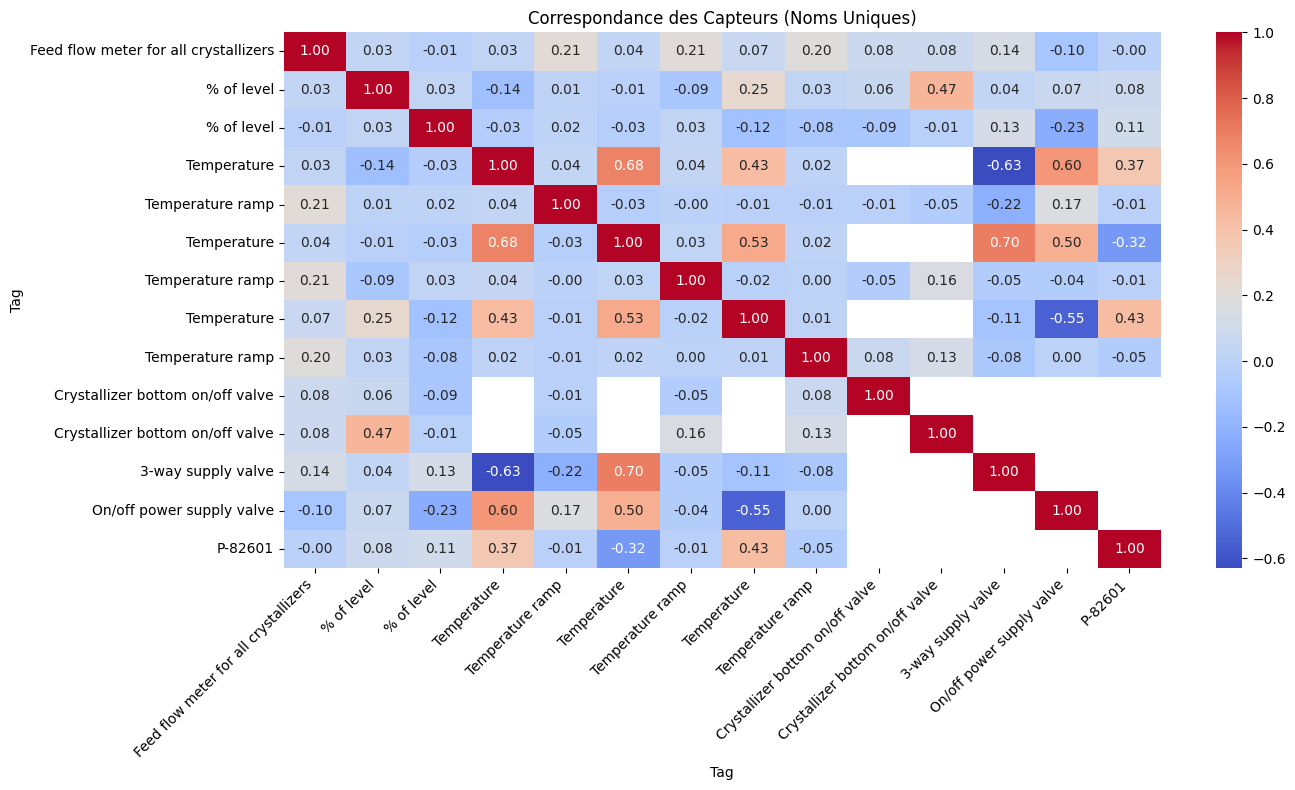

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(df_pivot.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correspondance des Capteurs (Noms Uniques)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# On crée une chaîne de caractères combinant l'ID et la Description
# Résultat attendu : "826TRC07 - Temperature" au lieu de juste "Temperature"
df_instruments['Unique_Label'] = df_instruments['Instrument TAG ID'].astype(str) + " (" + df_instruments['Instrument Description'].astype(str) + ")"

# On recrée le dictionnaire de mapping
mapping_unique = dict(zip(df_instruments['Instrument TAG ID'], df_instruments['Unique_Label']))

# On l'applique au DataFrame pivoté
df_pivot.columns = [mapping_unique.get(col, col) for col in df_pivot.columns]

# Vérification immédiate
print("Nouveaux noms de colonnes :")
for col in df_pivot.columns:
    print(f"- {col}")

Nouveaux noms de colonnes :
- Feed flow meter for all crystallizers
- % of level
- % of level
- Temperature
- Temperature ramp
- Temperature
- Temperature ramp
- Temperature
- Temperature ramp
- Crystallizer bottom on/off valve
- Crystallizer bottom on/off valve
- 3-way supply valve
- On/off power supply valve
- P-82601


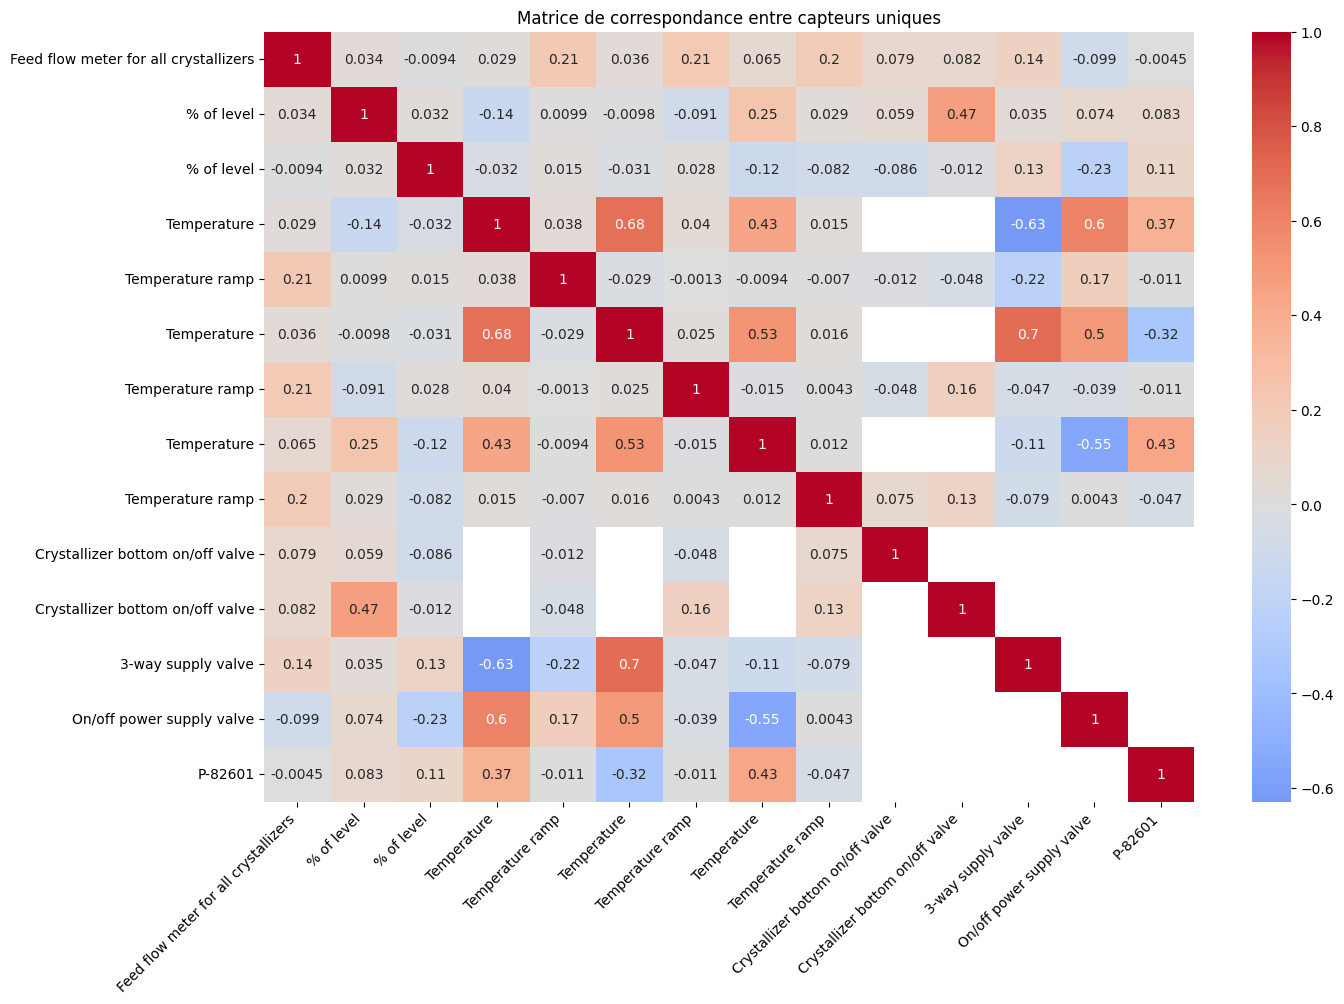

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

sns.heatmap(df_pivot.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de correspondance entre capteurs uniques')
plt.xticks(rotation=45, ha='right')
plt.show()  

In [23]:
# On s'assure que les colonnes de jointure n'ont pas d'espaces cachés
df_mesures['Tag'] = df_mesures['Tag'].str.strip()
df_instruments['Instrument TAG ID'] = df_instruments['Instrument TAG ID'].str.strip()

# On fusionne pour apporter les infos du référentiel dans le dataset de mesures
df_complet = df_mesures.merge(
    df_instruments[['Instrument TAG ID', 'Equipement Type', 'Instrument Description']], 
    left_on='Tag', 
    right_on='Instrument TAG ID', 
    how='left'
)

# On crée un nom VRAIMENT unique qui combine l'équipement et le tag
# Exemple : "CRYSTALLIZER 1 - 826TRC07 (Temperature)"
df_complet['Nom_Unique'] = (
    df_complet['Equipement Type'] + " - " + 
    df_complet['Tag'] + " (" + 
    df_complet['Instrument Description'] + ")"
)

In [24]:
df_complet.head()

,Unnamed: 0,Tag,Value,Measure_Date,nom de campagne,Instrument TAG ID,Equipement Type,Instrument Description,Nom_Unique
0,0,826LR06,1.24,2025-08-28 23:00:44,Kampagne 5,826LR06,CRYSTALLIZER 3,% of level,CRYSTALLIZER 3 - 826LR06 (% of level)
1,1,826LR06,1.24,2025-08-28 23:00:45,Kampagne 5,826LR06,CRYSTALLIZER 3,% of level,CRYSTALLIZER 3 - 826LR06 (% of level)
2,2,826LR06,1.24,2025-08-28 23:00:46,Kampagne 5,826LR06,CRYSTALLIZER 3,% of level,CRYSTALLIZER 3 - 826LR06 (% of level)
3,3,826LR06,1.24,2025-08-28 23:00:47,Kampagne 5,826LR06,CRYSTALLIZER 3,% of level,CRYSTALLIZER 3 - 826LR06 (% of level)
4,4,826LR06,1.25,2025-08-28 23:00:48,Kampagne 5,826LR06,CRYSTALLIZER 3,% of level,CRYSTALLIZER 3 - 826LR06 (% of level)


In [25]:
df_pivot = df_complet.pivot_table(
    index='Measure_Date', 
    columns='Nom_Unique', 
    values='Value',
    aggfunc='mean'
)


print(f"Noms de colonnes dupliqués : {df_pivot.columns.duplicated().sum()}")

Noms de colonnes dupliqués : 0


In [26]:
df_pivot.head()

Nom_Unique,CRYSTALLIZER 1 - 826TRC07 (Temperature),CRYSTALLIZER 1 - 826TRC07_DeltaT (Temperature ramp),CRYSTALLIZER 1 - 826XV01 (Crystallizer bottom on/off valve),CRYSTALLIZER 1 - 826XV16 (3-way supply valve),CRYSTALLIZER 2 - 826LR05 (% of level),CRYSTALLIZER 2 - 826TRC08 (Temperature),CRYSTALLIZER 2 - 826TRC08_DeltaT (Temperature ramp),CRYSTALLIZER 2 - 826XV14 (Crystallizer bottom on/off valve),CRYSTALLIZER 2 - 826XV16 (3-way supply valve),CRYSTALLIZER 3 - 826LR06 (% of level),CRYSTALLIZER 3 - 826TRC09 (Temperature),CRYSTALLIZER 3 - 826TRC09_DeltaT (Temperature ramp),CRYSTALLIZER 3 - 826XV18 (On/off power supply valve),Common 826 - 826FQR23 (Feed flow meter for all crystallizers)
Measure_Date,,,,,,,,,,,,,,
2025-08-27 11:00:45,NaN,NaN,NaN,NaN,-0.03,NaN,NaN,NaN,NaN,1.13,NaN,NaN,NaN,NaN
2025-08-27 11:00:46,NaN,NaN,NaN,NaN,-0.03,NaN,NaN,NaN,NaN,1.13,NaN,NaN,NaN,-4.07
2025-08-27 11:00:47,NaN,NaN,NaN,NaN,-0.03,NaN,NaN,NaN,NaN,1.13,NaN,NaN,NaN,-4.03
2025-08-27 11:00:48,NaN,NaN,NaN,NaN,-0.03,NaN,NaN,NaN,NaN,1.13,NaN,NaN,NaN,-4.07
2025-08-27 11:00:49,25.93,0.0,NaN,NaN,-0.03,25.72,0.0,NaN,NaN,1.13,25.45,0.0,NaN,-3.87


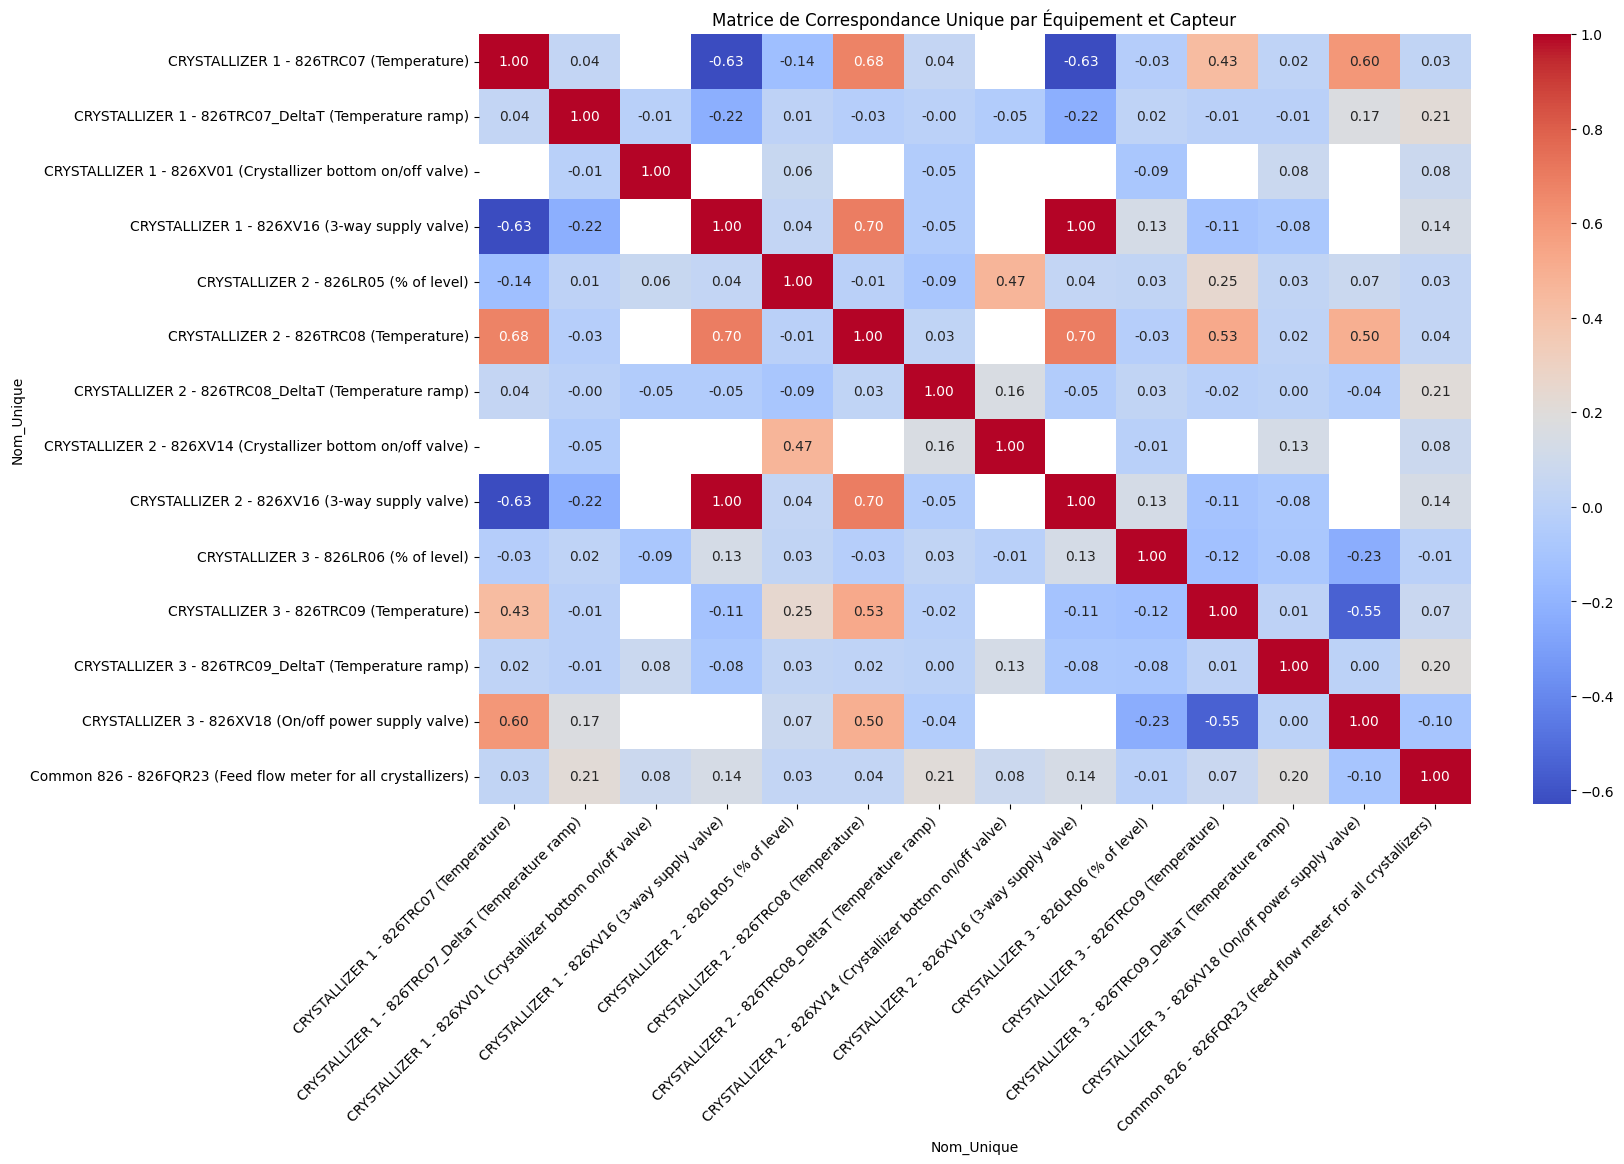

In [27]:
plt.figure(figsize=(16, 10))
sns.heatmap(df_pivot.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha='right')
plt.title('Matrice de Correspondance Unique par Équipement et Capteur')
plt.show()

In [28]:
df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot.sort_index()

In [29]:

df_pivot_clean = df_pivot.interpolate(method='time', limit_direction='both')

In [30]:
df_pivot_clean.head()

Nom_Unique,CRYSTALLIZER 1 - 826TRC07 (Temperature),CRYSTALLIZER 1 - 826TRC07_DeltaT (Temperature ramp),CRYSTALLIZER 1 - 826XV01 (Crystallizer bottom on/off valve),CRYSTALLIZER 1 - 826XV16 (3-way supply valve),CRYSTALLIZER 2 - 826LR05 (% of level),CRYSTALLIZER 2 - 826TRC08 (Temperature),CRYSTALLIZER 2 - 826TRC08_DeltaT (Temperature ramp),CRYSTALLIZER 2 - 826XV14 (Crystallizer bottom on/off valve),CRYSTALLIZER 2 - 826XV16 (3-way supply valve),CRYSTALLIZER 3 - 826LR06 (% of level),CRYSTALLIZER 3 - 826TRC09 (Temperature),CRYSTALLIZER 3 - 826TRC09_DeltaT (Temperature ramp),CRYSTALLIZER 3 - 826XV18 (On/off power supply valve),Common 826 - 826FQR23 (Feed flow meter for all crystallizers)
Measure_Date,,,,,,,,,,,,,,
2025-08-27 11:00:45,25.93,0.0,1.0,1.0,-0.03,25.72,0.0,1.0,1.0,1.13,25.45,0.0,1.0,-4.07
2025-08-27 11:00:46,25.93,0.0,1.0,1.0,-0.03,25.72,0.0,1.0,1.0,1.13,25.45,0.0,1.0,-4.07
2025-08-27 11:00:47,25.93,0.0,1.0,1.0,-0.03,25.72,0.0,1.0,1.0,1.13,25.45,0.0,1.0,-4.03
2025-08-27 11:00:48,25.93,0.0,1.0,1.0,-0.03,25.72,0.0,1.0,1.0,1.13,25.45,0.0,1.0,-4.07
2025-08-27 11:00:49,25.93,0.0,1.0,1.0,-0.03,25.72,0.0,1.0,1.0,1.13,25.45,0.0,1.0,-3.87


In [31]:
# 1. Supprimer les colonnes qui ont plus de 50% de valeurs manquantes
df_pivot_clean = df_pivot_clean.dropna(thresh=len(df_pivot_clean) * 0.5, axis=1)

# 2. Supprimer les quelques lignes restantes qui ont encore des NaN
df_pivot_final = df_pivot_clean.dropna()

print(f"Forme finale du dataset : {df_pivot_final.shape}")

Forme finale du dataset : (3799310, 14)


In [32]:
# On prend la moyenne par tranche de 10 secondes
# Puis on utilise ffill() pour porter la dernière valeur connue si une tranche est vide
df_pivot_resampled = df_pivot.resample('10S').mean().ffill()

C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_1256\4233970313.py:3: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_pivot_resampled = df_pivot.resample('10S').mean().ffill()


In [33]:
# Supprimer les colonnes qui ont une variance de 0 (toutes les valeurs sont identiques)
constant_cols = [col for col in df_pivot.columns if df_pivot[col].nunique() <= 1]
df_reduced = df_pivot.drop(columns=constant_cols)

print(f"Colonnes supprimées car constantes : {constant_cols}")

Colonnes supprimées car constantes : []


In [34]:
from sklearn.preprocessing import StandardScaler

# On initialise le scaler
scaler = StandardScaler()

# On crée le dataset normalisé (numpy array)
df_scaled = scaler.fit_transform(df_reduced)

# On le remet en DataFrame pour garder les noms de colonnes
df_final = pd.DataFrame(df_scaled, columns=df_reduced.columns, index=df_reduced.index)

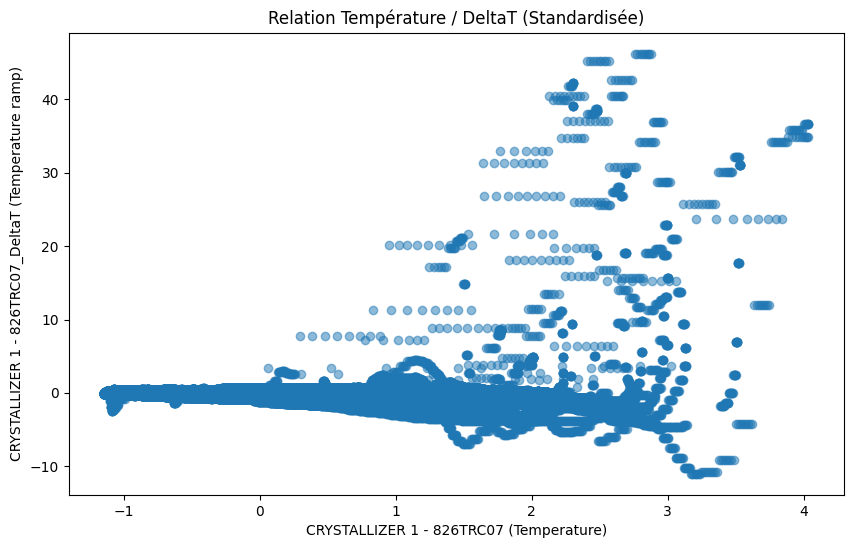

In [35]:
import matplotlib.pyplot as plt

# Exemple : Température vs DeltaT pour le Cristalliseur 1
plt.figure(figsize=(10, 6))
plt.scatter(df_final.iloc[:, 0], df_final.iloc[:, 1], alpha=0.5)
plt.xlabel(df_final.columns[0])
plt.ylabel(df_final.columns[1])
plt.title('Relation Température / DeltaT (Standardisée)')
plt.show()

In [36]:
# 1. On vérifie d'abord combien de NaNs il reste par colonne
print("Valeurs manquantes par capteur :")
print(df_final.isnull().sum())

# 2. Suppression des colonnes qui sont entièrement vides (si un capteur était HS)
df_final = df_final.dropna(axis=1, how='all')

# 3. Pour les trous restants au début/fin, on utilise ffill et bfill
df_final = df_final.ffill().bfill()

# 4. S'il reste encore des lignes avec des NaNs (cas rare), on les supprime
df_final = df_final.dropna()

# 5. Vérification finale : ce chiffre DOIT être 0
print(f"\nTotal de NaNs restants : {df_final.isnull().sum().sum()}")

Valeurs manquantes par capteur :
Nom_Unique
CRYSTALLIZER 1 - 826TRC07 (Temperature)                          3363517
CRYSTALLIZER 1 - 826TRC07_DeltaT (Temperature ramp)                12787
CRYSTALLIZER 1 - 826XV01 (Crystallizer bottom on/off valve)      3799257
CRYSTALLIZER 1 - 826XV16 (3-way supply valve)                    3799253
CRYSTALLIZER 2 - 826LR05 (% of level)                              12799
CRYSTALLIZER 2 - 826TRC08 (Temperature)                          3363205
CRYSTALLIZER 2 - 826TRC08_DeltaT (Temperature ramp)                14993
CRYSTALLIZER 2 - 826XV14 (Crystallizer bottom on/off valve)      3799274
CRYSTALLIZER 2 - 826XV16 (3-way supply valve)                    3799253
CRYSTALLIZER 3 - 826LR06 (% of level)                              28759
CRYSTALLIZER 3 - 826TRC09 (Temperature)                          3363863
CRYSTALLIZER 3 - 826TRC09_DeltaT (Temperature ramp)                14322
CRYSTALLIZER 3 - 826XV18 (On/off power supply valve)             3799266
Common 

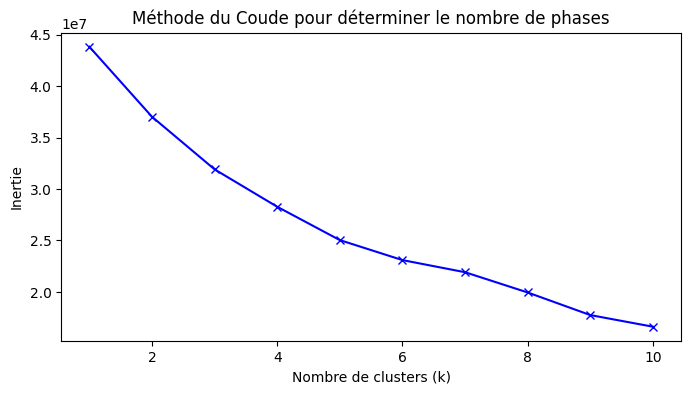

In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# On teste de 1 à 10 clusters
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_final) # On utilise les données standardisées
    inertia.append(kmeans.inertia_)

# Affichage du graphique du coude
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude pour déterminer le nombre de phases')
plt.show()

In [ ]:

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_pivot['Cluster'] = kmeans.fit_predict(df_final) 

# Regardons combien de points on a par cluster
print(df_pivot['Cluster'].value_counts())

Cluster
2    1596088
4     853142
1     783610
0     549330
3      17140
Name: count, dtype: int64


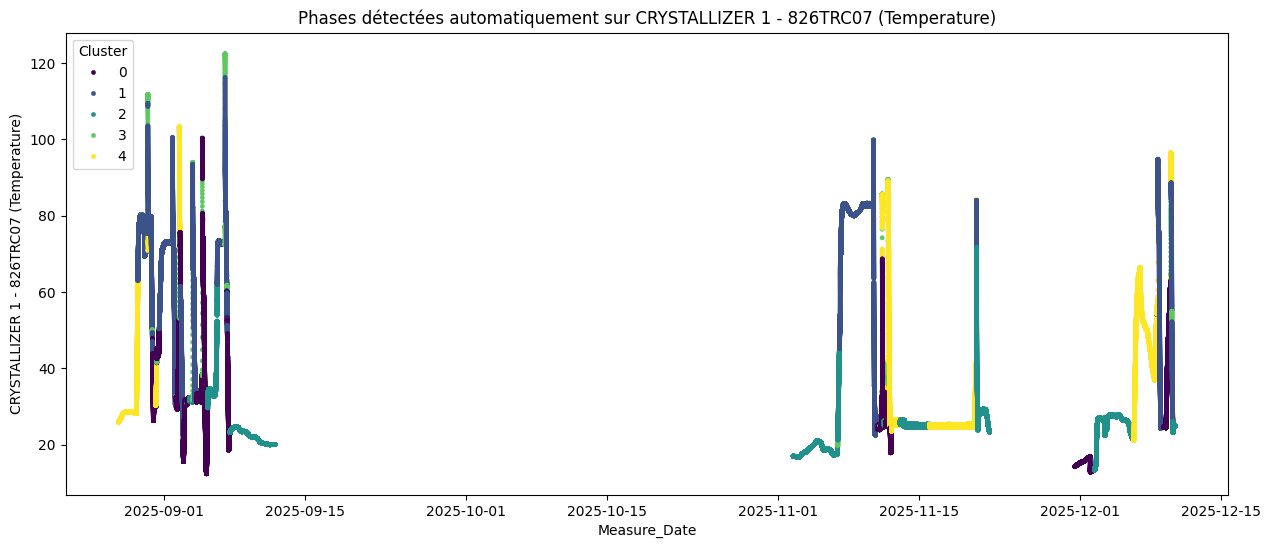

In [56]:
plt.figure(figsize=(15, 6))

sensor_name = 'CRYSTALLIZER 1 - 826TRC07 (Temperature)'

# On trace la courbe avec des couleurs différentes selon le cluster
sns.scatterplot(data=df_pivot, x=df_pivot.index, y=sensor_name, 
                hue='Cluster', palette='viridis', s=10, edgecolor=None)

plt.title(f'Phases détectées automatiquement sur {sensor_name}')
plt.show()

Profil moyen des capteurs par Cluster :


Nom_Unique,CRYSTALLIZER 1 - 826TRC07 (Temperature),CRYSTALLIZER 1 - 826TRC07_DeltaT (Temperature ramp),CRYSTALLIZER 1 - 826XV01 (Crystallizer bottom on/off valve),CRYSTALLIZER 1 - 826XV16 (3-way supply valve),CRYSTALLIZER 2 - 826LR05 (% of level),CRYSTALLIZER 2 - 826TRC08 (Temperature),CRYSTALLIZER 2 - 826TRC08_DeltaT (Temperature ramp),CRYSTALLIZER 2 - 826XV14 (Crystallizer bottom on/off valve),CRYSTALLIZER 2 - 826XV16 (3-way supply valve),CRYSTALLIZER 3 - 826LR06 (% of level),CRYSTALLIZER 3 - 826TRC09 (Temperature),CRYSTALLIZER 3 - 826TRC09_DeltaT (Temperature ramp),CRYSTALLIZER 3 - 826XV18 (On/off power supply valve),Common 826 - 826FQR23 (Feed flow meter for all crystallizers)
Cluster,,,,,,,,,,,,,,
0,28.957191,-0.006493,0.482759,0.421053,68.377766,34.021891,-0.057622,0.727273,0.421053,23.474930,50.487737,-0.002628,0.529412,-13.872427
1,69.055220,-0.030998,0.600000,0.352941,0.642307,65.572788,0.016175,0.375000,0.352941,20.564473,53.411317,-0.001175,0.545455,-29.951079
2,23.958295,0.000451,0.437500,0.000000,0.057043,22.156775,0.002499,0.300000,0.000000,23.692687,26.287063,-0.006322,0.400000,-14.359556
3,55.963319,1.608804,NaN,0.000000,28.316425,49.333740,0.740537,NaN,0.000000,28.564730,52.697593,0.527475,0.333333,6292.893512
4,33.210313,0.001855,0.000000,1.000000,3.181547,24.135860,0.004974,0.285714,1.000000,19.557305,29.124194,0.002086,0.000000,-5.183789


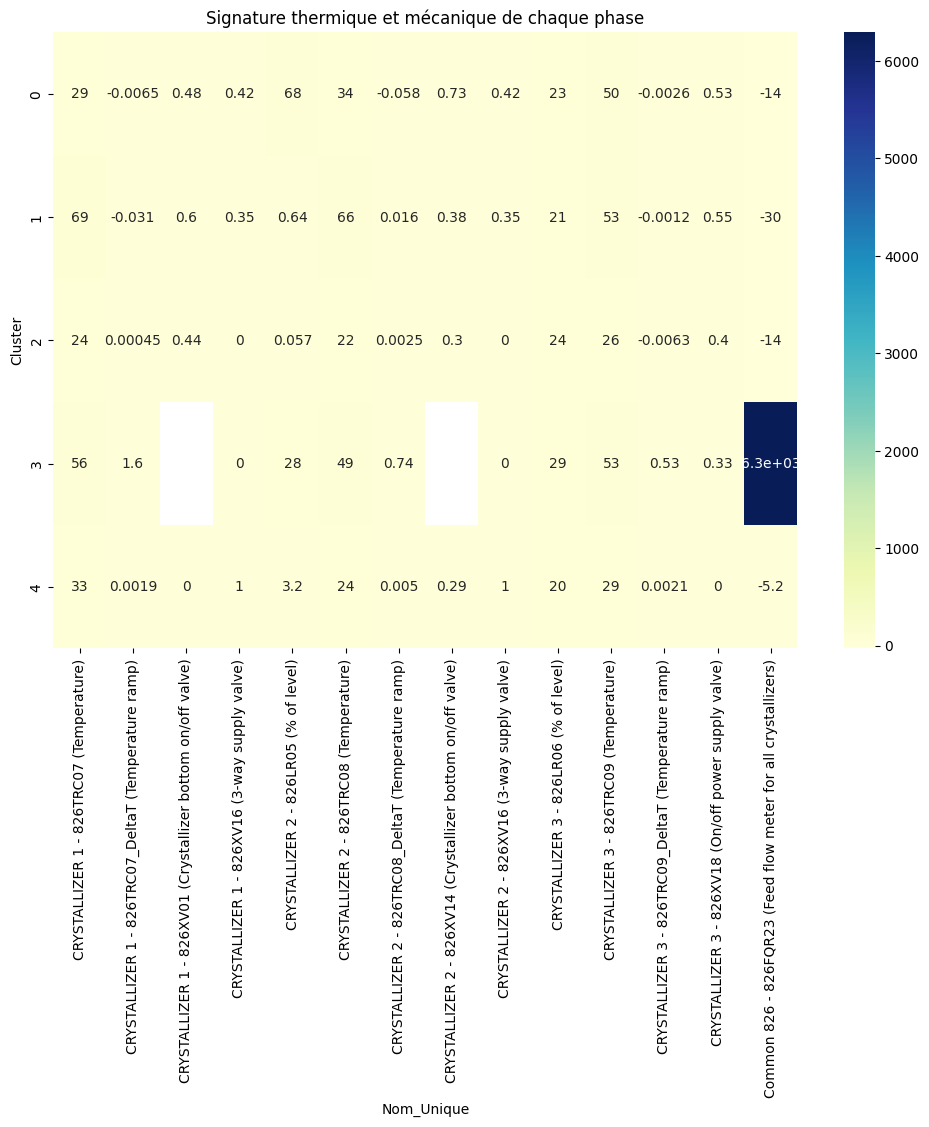

In [57]:
# 1. Calculer la moyenne de chaque capteur pour chaque cluster
profil_clusters = df_pivot.groupby('Cluster').mean()

# 2. Afficher le profil pour comprendre chaque phase
print("Profil moyen des capteurs par Cluster :")
display(profil_clusters)

# 3. Visualiser l'importance des variables
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(profil_clusters, annot=True, cmap='YlGnBu')
plt.title('Signature thermique et mécanique de chaque phase')
plt.show()

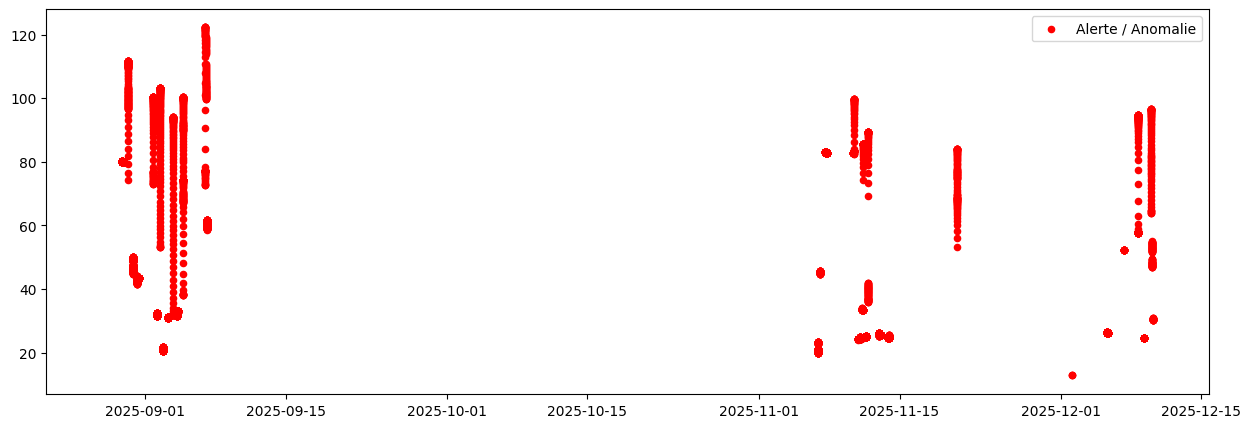

In [58]:
# Calcul de la distance de chaque point par rapport à son centre de cluster
distances = kmeans.transform(df_final)
min_distances = np.min(distances, axis=1)

# On définit un seuil (ex: le 99ème percentile des distances normales)
threshold = np.percentile(min_distances, 99)

# Si une nouvelle mesure dépasse ce seuil -> ALERTE
df_pivot['Is_Anomaly'] = min_distances > threshold

# Visualisation des anomalies sur le graphique
plt.figure(figsize=(15, 5))
plt.plot(df_pivot.index, df_pivot['CRYSTALLIZER 1 - 826TRC07 (Temperature)'], color='grey', alpha=0.5)
anomalies = df_pivot[df_pivot['Is_Anomaly'] == True]
plt.scatter(anomalies.index, anomalies['CRYSTALLIZER 1 - 826TRC07 (Temperature)'], color='red', s=20, label='Alerte / Anomalie')
plt.legend()
plt.show()

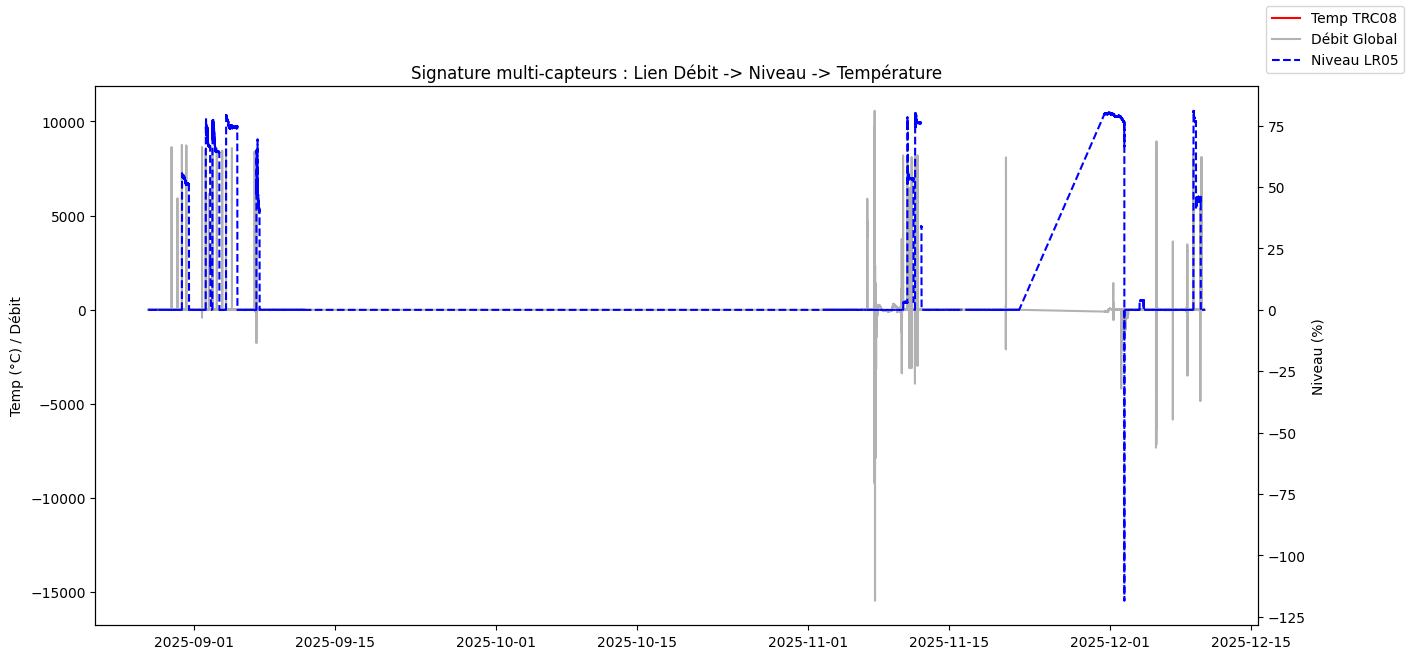

In [38]:
# Visualisation de la signature pour le Cristallisoir 2 (qui a TRC et LR)
fig, ax1 = plt.subplots(figsize=(15, 7))

# Axe 1 : Température et Débit
ax1.plot(df_pivot.index, df_pivot['CRYSTALLIZER 2 - 826TRC08 (Temperature)'], color='red', label='Temp TRC08')
ax1.plot(df_pivot.index, df_pivot['Common 826 - 826FQR23 (Feed flow meter for all crystallizers)'], color='black', alpha=0.3, label='Débit Global')
ax1.set_ylabel('Temp (°C) / Débit')

# Axe 2 : Niveau
ax2 = ax1.twinx()
ax2.plot(df_pivot.index, df_pivot['CRYSTALLIZER 2 - 826LR05 (% of level)'], color='blue', label='Niveau LR05', linestyle='--')
ax2.set_ylabel('Niveau (%)')

plt.title('Signature multi-capteurs : Lien Débit -> Niveau -> Température')
fig.legend(loc="upper right")
plt.show()

In [41]:
# On teste plusieurs décalages (en minutes)
for lag in [1, 5, 10, 20, 30]:
    corr = df_campagne['Common 826 - 826FQR23 (Feed flow meter for all crystallizers)'].shift(lag).corr(df_campagne['CRYSTALLIZER 2 - 826LR05 (% of level)'])
    print(f"Corrélation Débit/Niveau avec un retard de {lag} min : {corr:.3f}")

Corrélation Débit/Niveau avec un retard de 1 min : 0.072
Corrélation Débit/Niveau avec un retard de 5 min : 0.072
Corrélation Débit/Niveau avec un retard de 10 min : 0.072
Corrélation Débit/Niveau avec un retard de 20 min : 0.073
Corrélation Débit/Niveau avec un retard de 30 min : 0.074


In [43]:
from sklearn.cluster import KMeans

cols_c1 = [col for col in df_final.columns if 'CRYSTALLIZER 1' in col]
cols_c2 = [col for col in df_final.columns if 'CRYSTALLIZER 2' in col]
cols_c3 = [col for col in df_final.columns if 'CRYSTALLIZER 3' in col]

cols_c1.append('Common 826 - 826FQR23 (Feed flow meter for all crystallizers)')
cols_c2.append('Common 826 - 826FQR23 (Feed flow meter for all crystallizers)')
cols_c3.append('Common 826 - 826FQR23 (Feed flow meter for all crystallizers)')

def get_machine_clusters(df, columns, n_clusters=4):
    data = df[columns].dropna()
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    return km.fit_predict(data)

df_pivot['Cluster_C1'] = get_machine_clusters(df_final, cols_c1)
df_pivot['Cluster_C2'] = get_machine_clusters(df_final, cols_c2)


C:\Users\MohamedNadirHAMOU\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


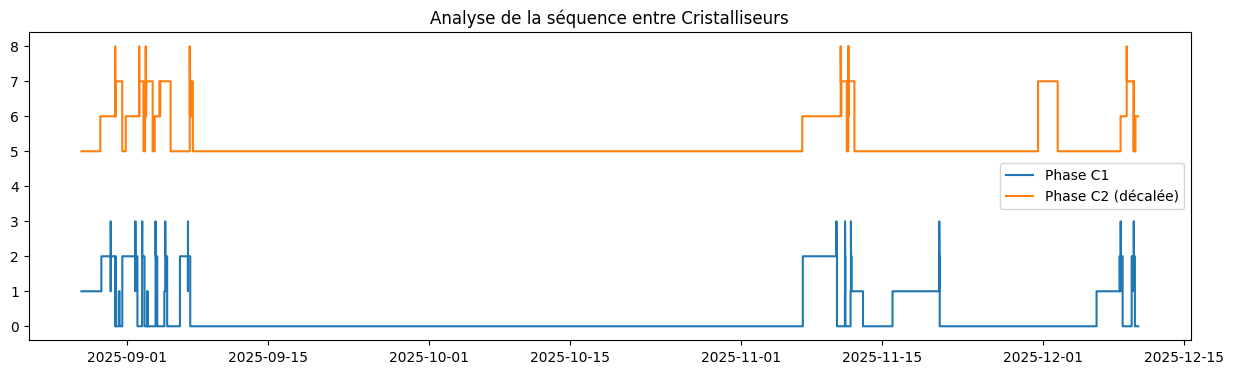

In [44]:
plt.figure(figsize=(15, 4))
plt.step(df_pivot.index, df_pivot['Cluster_C1'], label='Phase C1', where='post')
plt.step(df_pivot.index, df_pivot['Cluster_C2'] + 5, label='Phase C2 (décalée)', where='post') # +5 pour séparer visuellement
plt.title('Analyse de la séquence entre Cristalliseurs')
plt.legend()
plt.show()

In [ ]:
df_pivot['In_Cycle'] = df_pivot['CRYSTALLIZER 1 - 826TRC07 (Temperature)'] > 30

df_pivot['Cycle_ID'] = (df_pivot['In_Cycle'] != df_pivot['In_Cycle'].shift()).cumsum()

df_active = df_pivot[df_pivot['In_Cycle'] == True]